<a href="https://colab.research.google.com/github/ingkapat/Thai-Scam-Call-Detector/blob/main/experiment2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === Section 0: Install dependencies ===
!pip install -q transformers torchaudio librosa soundfile scikit-learn seaborn

In [2]:
# === Section 0: Mount Drive ===
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# === Section 0: Imports + Global Config ===
import os, json, time, glob, warnings, gc, re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import librosa

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_auc_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DRIVE_BASE      = '/content/drive/MyDrive/ThaiScamCall'
REAL_AUDIO_DIR  = f'{DRIVE_BASE}/real_audio'
OUT_DIR         = f'{DRIVE_BASE}/runs/experiment2'
TEXT_CLEAN      = f'{DRIVE_BASE}/models/phayathai_scam'
WHISPER_CLEAN   = f'{DRIVE_BASE}/models/whisper_enc_scam'

os.makedirs(REAL_AUDIO_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['not_scam', 'scam']
SR = 16000
WINDOWS_TO_TEST = [5, 10, 15, 20]
TEST_SET_F1 = {'two_stage': 0.9958, 'e2e': 0.9901}
OVERLAP_RATIO = 0.5    # 50% overlap for sliding mode

print(f'✅ Setup OK')
print(f'   Windows: {WINDOWS_TO_TEST}, Overlap: {OVERLAP_RATIO*100:.0f}%')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
✅ Setup OK
   Windows: [5, 10, 15, 20], Overlap: 50%


In [4]:
# === Section 1: Auto-create metadata.csv from filename ===
audio_files = sorted([f for f in os.listdir(REAL_AUDIO_DIR)
                      if f.endswith(('.mp3', '.wav', '.m4a'))])
assert audio_files, f'❌ ไม่มีไฟล์เสียงใน {REAL_AUDIO_DIR}'

def detect_label(fn):
    fn_lower = fn.lower()
    if 'notscam' in fn_lower or 'not_scam' in fn_lower: return 0
    if 'scam' in fn_lower: return 1
    return None

meta = pd.DataFrame([{
    'filename': f, 'label': detect_label(f),
    'speaker':  'tiktok', 'source': 'tiktok',
} for f in audio_files])

assert meta.label.notna().all(), '❌ มีไฟล์ที่ detect label ไม่ได้'
meta['label'] = meta.label.astype(int)
meta.to_csv(f'{REAL_AUDIO_DIR}/metadata.csv', index=False)

print(f'Total: {len(meta)} files')
print(meta.label.value_counts().rename({0: 'not_scam', 1: 'scam'}))
print()
print(meta.to_string(index=False))

Total: 19 files
label
scam        12
not_scam     7
Name: count, dtype: int64

        filename  label speaker source
rw_notscam01.mp3      0  tiktok tiktok
rw_notscam02.mp3      0  tiktok tiktok
rw_notscam03.mp3      0  tiktok tiktok
rw_notscam04.mp3      0  tiktok tiktok
rw_notscam05.mp3      0  tiktok tiktok
rw_notscam06.mp3      0  tiktok tiktok
rw_notscam07.mp3      0  tiktok tiktok
   rw_scam01.mp3      1  tiktok tiktok
   rw_scam02.mp3      1  tiktok tiktok
   rw_scam03.mp3      1  tiktok tiktok
   rw_scam04.mp3      1  tiktok tiktok
   rw_scam05.mp3      1  tiktok tiktok
   rw_scam06.mp3      1  tiktok tiktok
   rw_scam07.mp3      1  tiktok tiktok
   rw_scam08.mp3      1  tiktok tiktok
   rw_scam09.mp3      1  tiktok tiktok
   rw_scam10.mp3      1  tiktok tiktok
   rw_scam11.mp3      1  tiktok tiktok
   rw_scam12.mp3      1  tiktok tiktok


In [11]:
# === Section 1: Duration check per window size (with padding support) ===
durations = []
for fn in meta.filename:
    try:
        durations.append(librosa.get_duration(path=f'{REAL_AUDIO_DIR}/{fn}'))
    except Exception as e:
        print(f'❌ {fn}: {e}')
        durations.append(None)

meta['duration'] = durations

PAD_RATIO_LIMIT = 0.30  # pad ได้สูงสุด 30% ของ window

print(f'{"filename":<25} {"label":>5} {"duration":>9}  ', end='')
for w in WINDOWS_TO_TEST: print(f'{w}s   ', end='')
print('\n' + '-' * 80)

for _, r in meta.iterrows():
    print(f'{r.filename:<25} {r.label:>5} {r.duration:>7.1f}s  ', end='')
    for w in WINDOWS_TO_TEST:
        if r.duration >= w:
            print(f'{"✅":<4} ', end='')                  # ใช้ได้ตรง
        else:
            pad_ratio = (w - r.duration) / w
            if pad_ratio <= PAD_RATIO_LIMIT:
                print(f'{"🔧":<4} ', end='')              # pad ได้
            else:
                print(f'{"❌":<4} ', end='')              # pad เยอะเกิน
    print()

print(f'\nLegend: ✅ ใช้ได้ตรง | 🔧 ต้อง pad silence (≤{PAD_RATIO_LIMIT:.0%}) | ❌ pad เยอะเกิน skip')

print('\n=== สรุปจำนวนไฟล์ที่ใช้ได้ (ใช้ได้ + pad) ===')
for w in WINDOWS_TO_TEST:
    native_ok = meta.duration >= w
    pad_ok    = (meta.duration < w) & ((w - meta.duration) / w <= PAD_RATIO_LIMIT)
    usable    = native_ok | pad_ok
    n_native  = native_ok.sum()
    n_padded  = pad_ok.sum()
    by_class  = meta[usable].label.value_counts().to_dict()
    print(f'  Window {w:>2}s: {usable.sum()}/{len(meta)} ไฟล์  '
          f'(native {n_native} + pad {n_padded})  '
          f'(scam={by_class.get(1, 0)}, not_scam={by_class.get(0, 0)})')

# ไม่ filter ไฟล์ออก — pad ใน sliding function ที่ Cell ถัดไป
meta = meta.reset_index(drop=True)
print(f'\n✅ พร้อมใช้: {len(meta)} ไฟล์ (สั้นกว่า window จะ pad silence อัตโนมัติ)')

filename                  label  duration  5s   10s   15s   20s   
--------------------------------------------------------------------------------
rw_notscam01.mp3              0    42.3s  ✅    ✅    ✅    ✅    
rw_notscam02.mp3              0    72.4s  ✅    ✅    ✅    ✅    
rw_notscam03.mp3              0    30.4s  ✅    ✅    ✅    ✅    
rw_notscam04.mp3              0    75.2s  ✅    ✅    ✅    ✅    
rw_notscam05.mp3              0    46.3s  ✅    ✅    ✅    ✅    
rw_notscam06.mp3              0    57.9s  ✅    ✅    ✅    ✅    
rw_notscam07.mp3              0   111.7s  ✅    ✅    ✅    ✅    
rw_scam01.mp3                 1   110.7s  ✅    ✅    ✅    ✅    
rw_scam02.mp3                 1   636.2s  ✅    ✅    ✅    ✅    
rw_scam03.mp3                 1   210.2s  ✅    ✅    ✅    ✅    
rw_scam04.mp3                 1    76.1s  ✅    ✅    ✅    ✅    
rw_scam05.mp3                 1    19.9s  ✅    ✅    ✅    🔧    
rw_scam06.mp3                 1    60.0s  ✅    ✅    ✅    ✅    
rw_scam07.mp3                 1  

In [12]:
def predict_sliding(audio_path, predict_fn, window_sec, stride_sec=None, sr=SR):
    if stride_sec is None: stride_sec = window_sec
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr

    # 🆕 Pad silence ถ้าสั้นกว่า window
    if duration < window_sec:
        pad_ratio = (window_sec - duration) / window_sec
        if pad_ratio > 0.30:
            return pd.DataFrame()  # skip — pad เยอะเกินจะ dilute signal
        pad_samples = int((window_sec - duration) * sr)
        wav = np.pad(wav, (0, pad_samples), mode='constant', constant_values=0)
        duration = len(wav) / sr  # update duration หลัง pad

    rows = []
    for start in np.arange(0, duration - window_sec + 0.1, stride_sec):
        chunk = wav[int(start*sr):int((start+window_sec)*sr)]
        t0 = time.time()
        prob, transcript = predict_fn(chunk)
        rows.append({
            'window_start_sec': float(start),
            'window_end_sec':   float(start + window_sec),
            'prob_scam':        float(prob),
            'pred':             int(prob > 0.5),
            'latency':          time.time() - t0,
            'transcript':       transcript[:200] if transcript else '',
        })
    return pd.DataFrame(rows)

In [13]:
# === Section 2: Load 3 models for inference ===
from transformers import (AutoProcessor, AutoModelForSpeechSeq2Seq,
                          AutoTokenizer, AutoModelForSequenceClassification,
                          AutoFeatureExtractor, AutoModelForAudioClassification)

ASR_MODEL_ID = 'biodatlab/whisper-th-medium-combined'

asr_processor = AutoProcessor.from_pretrained(ASR_MODEL_ID)
asr_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    ASR_MODEL_ID, torch_dtype=torch.float16 if device == 'cuda' else torch.float32
).to(device).eval()
asr_forced_ids = asr_processor.get_decoder_prompt_ids(language='th', task='transcribe')
print('✅ ASR loaded')

text_tok = AutoTokenizer.from_pretrained(TEXT_CLEAN)
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_CLEAN).to(device).eval()
print('✅ Text classifier loaded')

whisper_fe = AutoFeatureExtractor.from_pretrained(WHISPER_CLEAN)
whisper_model = AutoModelForAudioClassification.from_pretrained(WHISPER_CLEAN).to(device).eval()
print('✅ Whisper E2E loaded')

Loading weights:   0%|          | 0/948 [00:00<?, ?it/s]

✅ ASR loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Text classifier loaded


Loading weights:   0%|          | 0/191 [00:00<?, ?it/s]

✅ Whisper E2E loaded


In [14]:
# === Section 3: Basic inference functions (per chunk) ===
@torch.no_grad()
def asr_transcribe(audio_chunk, sr=SR):
    inputs = asr_processor(audio_chunk, sampling_rate=sr, return_tensors='pt')
    inputs = {k: v.to(device, dtype=asr_model.dtype if v.dtype == torch.float32 else v.dtype)
              for k, v in inputs.items()}
    gen = asr_model.generate(**inputs, forced_decoder_ids=asr_forced_ids, max_new_tokens=128)
    return asr_processor.batch_decode(gen, skip_special_tokens=True)[0]

@torch.no_grad()
def text_classify(text):
    enc = text_tok(text, truncation=True, max_length=256, return_tensors='pt').to(device)
    logits = text_model(**enc).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()[0]

@torch.no_grad()
def whisper_classify(audio_chunk, sr=SR):
    inputs = whisper_fe(audio_chunk, sampling_rate=sr, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    logits = whisper_model(**inputs).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()[0]

def predict_two_stage(audio_chunk):
    text = asr_transcribe(audio_chunk)
    return text_classify(text), text

def predict_e2e(audio_chunk):
    return whisper_classify(audio_chunk), ''

print('✅ Basic inference functions ready')

✅ Basic inference functions ready


In [15]:
# === Section 3: 3 prediction modes + aggregation ===

# Mode 1: Sliding window (overlap supported)
def predict_sliding(audio_path, predict_fn, window_sec, stride_sec=None, sr=SR):
    if stride_sec is None: stride_sec = window_sec
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr
    rows = []
    for start in np.arange(0, duration - window_sec + 0.1, stride_sec):
        chunk = wav[int(start*sr):int((start+window_sec)*sr)]
        t0 = time.time()
        prob, transcript = predict_fn(chunk)
        rows.append({
            'start_sec': float(start), 'end_sec': float(start + window_sec),
            'prob_scam': float(prob[1]), 'pred': int(prob[1] > 0.5),
            'latency': time.time() - t0, 'transcript': transcript,
        })
    return pd.DataFrame(rows)

# Mode 2: Streaming Concat (Two-stage only)
def predict_two_stage_streaming(audio_path, chunk_sec=5, max_text_len=2000, sr=SR):
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr
    accumulated_text = ''
    rows = []
    for start in np.arange(0, duration - chunk_sec + 0.1, chunk_sec):
        chunk = wav[int(start*sr):int((start+chunk_sec)*sr)]
        t0 = time.time()
        new_text = asr_transcribe(chunk)
        accumulated_text = (accumulated_text + ' ' + new_text).strip()
        if len(accumulated_text) > max_text_len:
            accumulated_text = accumulated_text[-max_text_len:]
        prob = text_classify(accumulated_text)
        rows.append({
            'start_sec': float(start), 'end_sec': float(start + chunk_sec),
            'prob_scam': float(prob[1]), 'pred': int(prob[1] > 0.5),
            'latency': time.time() - t0, 'transcript': accumulated_text[:300],
        })
    return pd.DataFrame(rows)

# Mode 3: Growing Audio Window (E2E)
def predict_e2e_growing(audio_path, step_sec=5, max_sec=30, sr=SR):
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr
    rows = []
    for end in np.arange(step_sec, duration + 0.1, step_sec):
        start = 0 if end <= max_sec else end - max_sec
        chunk = wav[int(start*sr):int(end*sr)]
        t0 = time.time()
        prob = whisper_classify(chunk)
        rows.append({
            'start_sec': float(start), 'end_sec': float(end),
            'prob_scam': float(prob[1]), 'pred': int(prob[1] > 0.5),
            'latency': time.time() - t0, 'transcript': '',
        })
    return pd.DataFrame(rows)

# Aggregation helpers
def aggregate_windows(window_df, strategy='max'):
    if strategy == 'any': return int((window_df.prob_scam > 0.5).any())
    if strategy == 'max':
        idx = (window_df.prob_scam - 0.5).abs().idxmax()
        return int(window_df.loc[idx, 'pred'])
    if strategy == 'mean': return int(window_df.prob_scam.mean() > 0.5)
    if strategy == 'majority': return int(window_df.pred.sum() > len(window_df) / 2)
    raise ValueError(strategy)

def time_to_first_detection(window_df, threshold=0.7):
    triggered = window_df[window_df.prob_scam > threshold]
    return None if len(triggered) == 0 else float(triggered.iloc[0].end_sec)

print('✅ 3 prediction modes ready: sliding / streaming / growing')

✅ 3 prediction modes ready: sliding / streaming / growing


In [16]:
# === Section 4: Run all experiments — 3 modes × 2 models ===
EXPERIMENTS = []
for w in WINDOWS_TO_TEST:
    stride = w * (1 - OVERLAP_RATIO)
    EXPERIMENTS.append({'name': f'two_stage_sliding_{w}s', 'mode': 'sliding',
                        'model': 'two_stage', 'window': w, 'stride': stride})
    EXPERIMENTS.append({'name': f'e2e_sliding_{w}s', 'mode': 'sliding',
                        'model': 'e2e', 'window': w, 'stride': stride})
EXPERIMENTS.append({'name': 'two_stage_streaming', 'mode': 'streaming',
                    'model': 'two_stage', 'chunk_sec': 5})
EXPERIMENTS.append({'name': 'e2e_growing', 'mode': 'growing',
                    'model': 'e2e', 'step_sec': 5, 'max_sec': 30})

print(f'จะรัน {len(EXPERIMENTS)} experiments\n')
for exp in EXPERIMENTS:
    print(f'  {exp["name"]:<28} mode={exp["mode"]}')
print()

all_window_results = {}

for exp in EXPERIMENTS:
    print(f'\n=== {exp["name"]} (mode={exp["mode"]}) ===')
    min_dur = exp.get('window') or exp.get('chunk_sec') or exp.get('step_sec')
    meta_for_exp = meta[meta.duration >= min_dur].reset_index(drop=True)
    n_skip = len(meta) - len(meta_for_exp)
    if n_skip: print(f'  Skip {n_skip} ไฟล์สั้นเกิน')
    if len(meta_for_exp) == 0: continue

    rows = []
    for _, m in tqdm(meta_for_exp.iterrows(), total=len(meta_for_exp), desc=exp['name']):
        try:
            audio_path = f'{REAL_AUDIO_DIR}/{m.filename}'
            if exp['mode'] == 'sliding':
                predict_fn = predict_two_stage if exp['model'] == 'two_stage' else predict_e2e
                wdf = predict_sliding(audio_path, predict_fn,
                                       window_sec=exp['window'], stride_sec=exp['stride'])
            elif exp['mode'] == 'streaming':
                wdf = predict_two_stage_streaming(audio_path, chunk_sec=exp['chunk_sec'])
            elif exp['mode'] == 'growing':
                wdf = predict_e2e_growing(audio_path, step_sec=exp['step_sec'],
                                          max_sec=exp['max_sec'])
        except Exception as e:
            print(f'❌ {m.filename}: {e}')
            continue
        if len(wdf) == 0: continue
        wdf['filename'] = m.filename
        wdf['true_label'] = m.label
        wdf['speaker'] = m.speaker
        rows.append(wdf)

    if rows:
        all_window_results[exp['name']] = pd.concat(rows, ignore_index=True, sort=False)
        all_window_results[exp['name']].to_csv(f'{OUT_DIR}/{exp["name"]}_windows.csv', index=False)
        n_win = all_window_results[exp['name']].groupby('filename').size().mean()
        avg_lat = all_window_results[exp['name']].latency.mean()
        print(f'  → {n_win:.1f} windows/file, avg inference {avg_lat:.2f}s/window')

print(f'\n✅ Done — {len(all_window_results)} experiments')

จะรัน 10 experiments

  two_stage_sliding_5s         mode=sliding
  e2e_sliding_5s               mode=sliding
  two_stage_sliding_10s        mode=sliding
  e2e_sliding_10s              mode=sliding
  two_stage_sliding_15s        mode=sliding
  e2e_sliding_15s              mode=sliding
  two_stage_sliding_20s        mode=sliding
  e2e_sliding_20s              mode=sliding
  two_stage_streaming          mode=streaming
  e2e_growing                  mode=growing


=== two_stage_sliding_5s (mode=sliding) ===


two_stage_sliding_5s:   0%|          | 0/19 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  → 46.9 windows/file, avg inference 1.15s/window

=== e2e_sliding_5s (mode=sliding) ===


e2e_sliding_5s:   0%|          | 0/19 [00:00<?, ?it/s]

...

two_stage_streaming:   0%|          | 0/19 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  → 23.8 windows/file, avg inference 1.14s/window

=== e2e_growing (mode=growing) ===


e2e_growing:   0%|          | 0/19 [00:00<?, ?it/s]

  → 23.8 windows/file, avg inference 0.03s/window

✅ Done — 10 experiments


In [17]:
# === Section 5: Aggregate per call (4 strategies) ===
STRATEGIES = ['any', 'max', 'mean', 'majority']
summary_rows = []

for exp_name, wdf in all_window_results.items():
    for strategy in STRATEGIES:
        calls = []
        for fn, group in wdf.groupby('filename'):
            calls.append({
                'filename': fn,
                'true_label': group.true_label.iloc[0],
                'pred': aggregate_windows(group, strategy=strategy),
                'time_to_detect': time_to_first_detection(group),
                'total_latency': group.latency.sum(),
                'n_windows': len(group),
            })
        cdf = pd.DataFrame(calls)
        y, p = cdf.true_label.values, cdf.pred.values
        summary_rows.append({
            'experiment': exp_name, 'strategy': strategy,
            'accuracy':   accuracy_score(y, p),
            'macro_f1':   f1_score(y, p, average='macro'),
            'f1_scam':    f1_score(y, p, pos_label=1, zero_division=0),
            'avg_ttfd':   cdf.time_to_detect.mean(),
            'avg_latency': cdf.total_latency.mean(),
            'avg_n_windows': cdf.n_windows.mean(),
        })

summary = pd.DataFrame(summary_rows).round(4)
summary.to_csv(f'{OUT_DIR}/summary.csv', index=False)
display(summary)

,experiment,strategy,accuracy,macro_f1,f1_scam,avg_ttfd,avg_latency,avg_n_windows
0,two_stage_sliding_5s,any,0.7368,0.6360,0.8276,26.4062,54.2168,46.9474
1,two_stage_sliding_5s,max,0.6842,0.6833,0.6667,26.4062,54.2168,46.9474
2,two_stage_sliding_5s,mean,0.5789,0.5682,0.5000,26.4062,54.2168,46.9474
3,two_stage_sliding_5s,majority,0.5789,0.5682,0.5000,26.4062,54.2168,46.9474
4,e2e_sliding_5s,any,0.5789,0.5778,0.6000,77.1875,1.3756,46.9474
5,e2e_sliding_5s,max,0.3684,0.2692,0.0000,77.1875,1.3756,46.9474
6,e2e_sliding_5s,mean,0.3684,0.2692,0.0000,77.1875,1.3756,46.9474
7,e2e_sliding_5s,majority,0.3684,0.2692,0.0000,77.1875,1.3756,46.9474
8,two_stage_sliding_10s,any,0.8947,0.8782,0.9231,28.8462,49.5946,22.8421
9,two_stage_sliding_10s,max,0.7895,0.7889,0.8000,28.8462,49.5946,22.8421


In [18]:
# === Section 6: Best per experiment ===
best = summary.loc[summary.groupby('experiment').macro_f1.idxmax()].copy()

def parse_exp(name):
    if 'streaming' in name: return ('two_stage', 'streaming', None)
    if 'growing' in name:   return ('e2e', 'growing', None)
    model = 'two_stage' if name.startswith('two_stage') else 'e2e'
    w = int(name.split('_')[-1].replace('s', ''))
    return (model, 'sliding', w)

best[['model', 'mode', 'window']] = best.experiment.apply(
    lambda x: pd.Series(parse_exp(x)))
best['test_set_f1'] = best.model.map(TEST_SET_F1)
best['drop'] = best.test_set_f1 - best.macro_f1

print('=== Best per experiment vs Test set ===')
display(best[['experiment', 'mode', 'strategy', 'macro_f1', 'test_set_f1', 'drop',
              'avg_ttfd', 'avg_latency']].round(4))

=== Best per experiment vs Test set ===


,experiment,mode,strategy,macro_f1,test_set_f1,drop,avg_ttfd,avg_latency
36,e2e_growing,growing,any,0.6316,0.9901,0.3585,44.2857,0.6992
12,e2e_sliding_10s,sliding,any,0.6275,0.9901,0.3626,51.1111,0.6698
20,e2e_sliding_15s,sliding,any,0.6275,0.9901,0.3626,45.0000,0.4327
28,e2e_sliding_20s,sliding,any,0.6625,0.9901,0.3276,44.0000,0.3402
4,e2e_sliding_5s,sliding,any,0.5778,0.9901,0.4123,77.1875,1.3756
8,two_stage_sliding_10s,sliding,any,0.8782,0.9958,0.1176,28.8462,49.5946
16,two_stage_sliding_15s,sliding,any,0.9415,0.9958,0.0543,28.1250,42.9383
24,two_stage_sliding_20s,sliding,any,0.8831,0.9958,0.1127,40.9091,35.1160
1,two_stage_sliding_5s,sliding,max,0.6833,0.9958,0.3125,26.4062,54.2168
32,two_stage_streaming,streaming,any,0.8403,0.9958,0.1555,44.3750,27.1597


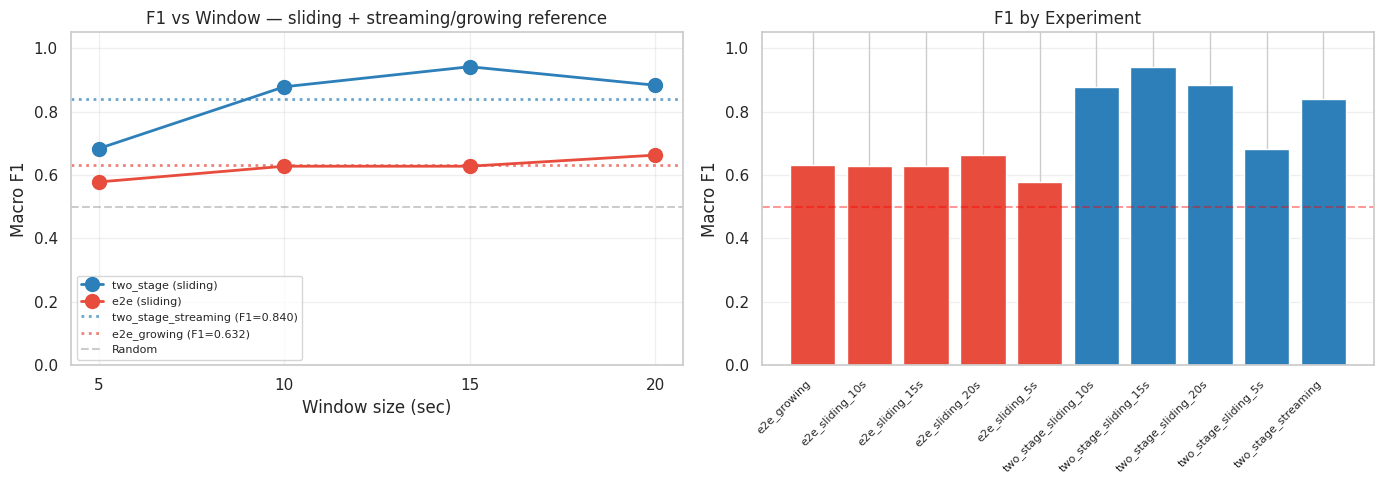


🎯 Best per mode:
  sliding    two_stage_sliding_15s        F1=0.942  latency=42.94s
  streaming  two_stage_streaming          F1=0.840  latency=27.16s
  growing    e2e_growing                  F1=0.632  latency=0.70s


In [19]:
# === Section 6: Mode comparison + window optimization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 vs Window (sliding) + streaming/growing reference
sliding = best[best['mode'] == 'sliding'].copy()
for model, color in [('two_stage', '#2c7fb8'), ('e2e', '#e74c3c')]:
    sub = sliding[sliding.model == model].sort_values('window')
    axes[0].plot(sub.window, sub.macro_f1, 'o-', label=f'{model} (sliding)',
                 markersize=10, linewidth=2, color=color)

streaming_row = best[best['mode'] == 'streaming']
if len(streaming_row):
    axes[0].axhline(streaming_row.iloc[0].macro_f1, color='#2c7fb8',
                    linestyle=':', linewidth=2, alpha=0.7,
                    label=f'two_stage_streaming (F1={streaming_row.iloc[0].macro_f1:.3f})')
growing_row = best[best['mode'] == 'growing']
if len(growing_row):
    axes[0].axhline(growing_row.iloc[0].macro_f1, color='#e74c3c',
                    linestyle=':', linewidth=2, alpha=0.7,
                    label=f'e2e_growing (F1={growing_row.iloc[0].macro_f1:.3f})')

axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Random')
axes[0].set_xlabel('Window size (sec)'); axes[0].set_ylabel('Macro F1')
axes[0].set_title('F1 vs Window — sliding + streaming/growing reference')
axes[0].legend(fontsize=8); axes[0].set_xticks(WINDOWS_TO_TEST)
axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# Plot 2: All experiments bar chart
axes[1].bar(np.arange(len(best)), best.macro_f1.values,
            color=['#2c7fb8' if m == 'two_stage' else '#e74c3c' for m in best.model])
axes[1].set_xticks(np.arange(len(best)))
axes[1].set_xticklabels(best.experiment, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Macro F1'); axes[1].set_title('F1 by Experiment')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.4)
axes[1].grid(alpha=0.3, axis='y'); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/mode_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🎯 Best per mode:')
for mode in ['sliding', 'streaming', 'growing']:
    sub = best[best['mode'] == mode]
    if len(sub) == 0: continue
    top = sub.sort_values('macro_f1', ascending=False).iloc[0]
    print(f'  {mode:<10} {top.experiment:<28} F1={top.macro_f1:.3f}  '
          f'latency={top.avg_latency:.2f}s')

Best: two_stage_sliding_15s | strategy=any

Errors: 1/19 (5.3%)


,filename,true,pred,speaker,mean_prob_scam,max_prob_scam,n_windows
0,rw_notscam07.mp3,not_scam,scam,tiktok,0.046307,0.574059,13


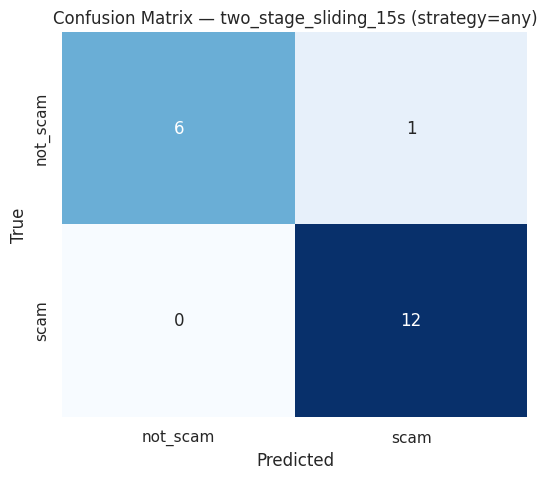

              precision    recall  f1-score   support

    not_scam     1.0000    0.8571    0.9231         7
        scam     0.9231    1.0000    0.9600        12

    accuracy                         0.9474        19
   macro avg     0.9615    0.9286    0.9415        19
weighted avg     0.9514    0.9474    0.9464        19



In [20]:
# === Section 7: Best overall + Error analysis + Confusion matrix ===
BEST_EXP = best.sort_values('macro_f1', ascending=False).iloc[0].experiment
BEST_STRAT = best[best.experiment == BEST_EXP].strategy.iloc[0]
print(f'Best: {BEST_EXP} | strategy={BEST_STRAT}\n')

wdf_best = all_window_results[BEST_EXP]
errors, calls = [], []
for fn, group in wdf_best.groupby('filename'):
    true_label = int(group.true_label.iloc[0])
    pred = aggregate_windows(group, strategy=BEST_STRAT)
    calls.append({'filename': fn, 'true': true_label, 'pred': pred})
    if pred != true_label:
        errors.append({
            'filename': fn,
            'true': CLASS_NAMES[true_label], 'pred': CLASS_NAMES[pred],
            'speaker': group.speaker.iloc[0],
            'mean_prob_scam': group.prob_scam.mean(),
            'max_prob_scam':  group.prob_scam.max(),
            'n_windows': len(group),
        })

calls_df = pd.DataFrame(calls)
err_df = pd.DataFrame(errors)
print(f'Errors: {len(err_df)}/{len(calls_df)} ({len(err_df)/len(calls_df)*100:.1f}%)')
if len(err_df) > 0:
    display(err_df)
    err_df.to_csv(f'{OUT_DIR}/errors.csv', index=False)

# Confusion matrix
cm_best = confusion_matrix(calls_df.true, calls_df.pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix — {BEST_EXP} (strategy={BEST_STRAT})')
plt.savefig(f'{OUT_DIR}/best_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(calls_df.true, calls_df.pred, target_names=CLASS_NAMES, digits=4))

{
  "experiment": "Experiment 2 — Real-world audio test (3 modes)",
  "n_files": 19,
  "class_dist": {
    "1": 12,
    "0": 7
  },
  "best_experiment": "two_stage_sliding_15s",
  "best_strategy": "any",
  "best_f1": 0.9415,
  "test_set_f1_ref": {
    "two_stage": 0.9958,
    "e2e": 0.9901
  },
  "generalization_gap": {
    "two_stage": 0.054300000000000015,
    "e2e": 0.3276
  }
}


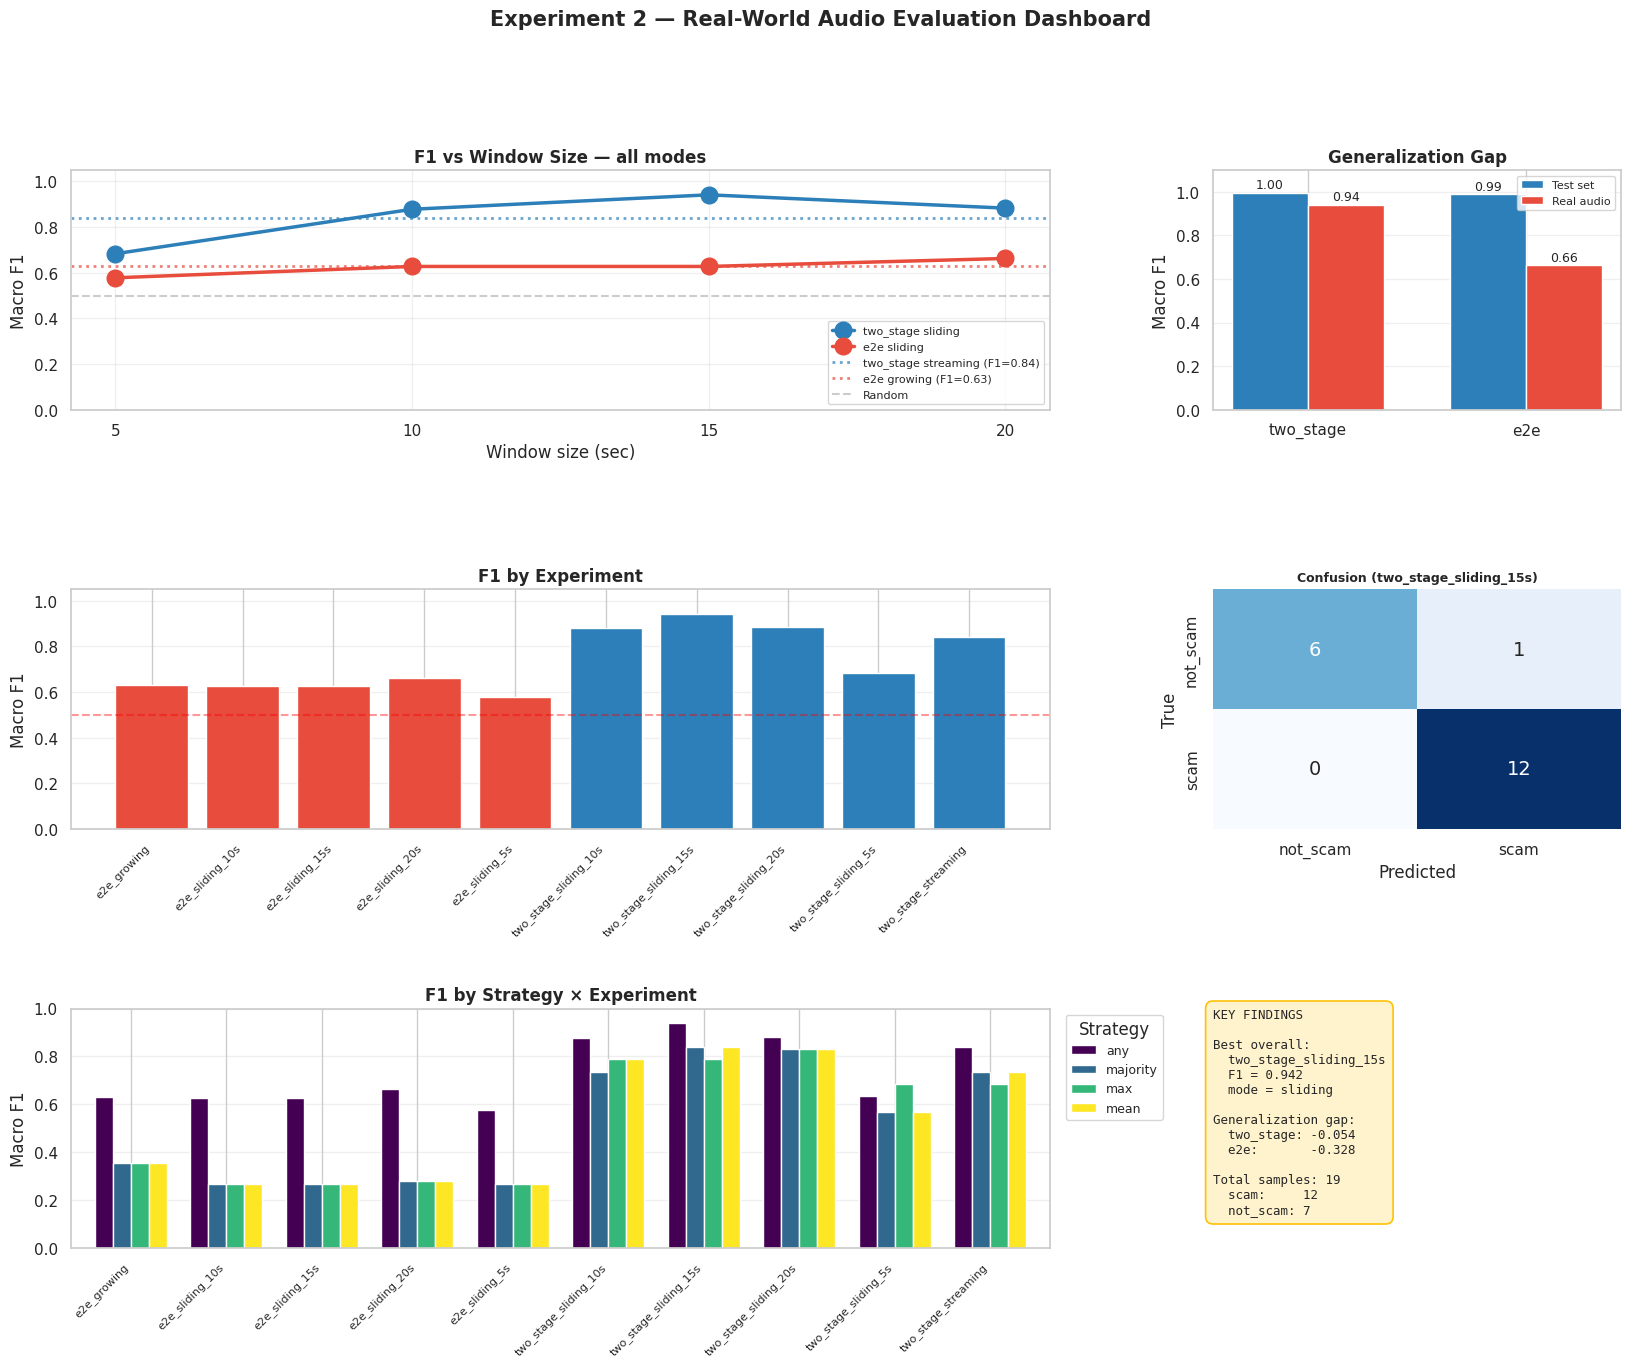


✅ Dashboard saved to /content/drive/MyDrive/ThaiScamCall/runs/experiment2/dashboard.png


In [23]:
# === Section 8: Save report.json + FINAL DASHBOARD ===
models_list = ['two_stage', 'e2e']
real_f1 = {m: best[best.model == m].macro_f1.max() for m in models_list}

report = {
    'experiment': 'Experiment 2 — Real-world audio test (3 modes)',
    'n_files': int(len(meta)),
    'class_dist': meta.label.value_counts().to_dict(),
    'best_experiment': BEST_EXP,
    'best_strategy':   BEST_STRAT,
    'best_f1':         float(best[best.experiment == BEST_EXP].macro_f1.iloc[0]),
    'test_set_f1_ref': TEST_SET_F1,
    'generalization_gap': {m: float(TEST_SET_F1[m] - real_f1[m]) for m in models_list},
}
with open(f'{OUT_DIR}/report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print(json.dumps(report, indent=2, ensure_ascii=False))

# Dashboard — 🔧 ขยาย figure + เพิ่ม spacing เพื่อรองรับชื่อเต็ม
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.75, wspace=0.40)   # 🔧 hspace 0.4 → 0.75

# Panel 1: F1 vs Window (sliding) + reference lines
ax1 = fig.add_subplot(gs[0, :2])
sliding = best[best['mode'] == 'sliding'].copy()
for model, color in [('two_stage', '#2c7fb8'), ('e2e', '#e74c3c')]:
    sub = sliding[sliding.model == model].sort_values('window')
    ax1.plot(sub.window, sub.macro_f1, 'o-', label=f'{model} sliding',
             markersize=12, linewidth=2.5, color=color)
if len(streaming_row):
    ax1.axhline(streaming_row.iloc[0].macro_f1, color='#2c7fb8',
                linestyle=':', linewidth=2, alpha=0.7,
                label=f'two_stage streaming (F1={streaming_row.iloc[0].macro_f1:.2f})')
if len(growing_row):
    ax1.axhline(growing_row.iloc[0].macro_f1, color='#e74c3c',
                linestyle=':', linewidth=2, alpha=0.7,
                label=f'e2e growing (F1={growing_row.iloc[0].macro_f1:.2f})')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Random')
ax1.set_xlabel('Window size (sec)')
ax1.set_ylabel('Macro F1')
ax1.set_title('F1 vs Window Size — all modes', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.set_xticks(WINDOWS_TO_TEST)
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)

# Panel 2: Generalization Gap (best per model)
ax2 = fig.add_subplot(gs[0, 2])
test_f1_list = [TEST_SET_F1[m] for m in models_list]
real_f1_list = [real_f1[m] for m in models_list]
x_pos = np.arange(len(models_list)); width = 0.35
ax2.bar(x_pos - width/2, test_f1_list, width, label='Test set', color='#2c7fb8')
ax2.bar(x_pos + width/2, real_f1_list, width, label='Real audio', color='#e74c3c')
for i, (t, r) in enumerate(zip(test_f1_list, real_f1_list)):
    ax2.text(i - width/2, t + 0.02, f'{t:.2f}', ha='center', fontsize=9)
    ax2.text(i + width/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_list)
ax2.set_ylabel('Macro F1')
ax2.set_title('Generalization Gap', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1.1)
ax2.grid(alpha=0.3, axis='y')

# Panel 3: All experiments bar chart — 🔧 rotation 45 + fontsize 8
ax3 = fig.add_subplot(gs[1, :2])
ax3.bar(np.arange(len(best)), best.macro_f1.values,
        color=['#2c7fb8' if m == 'two_stage' else '#e74c3c' for m in best.model])
ax3.set_xticks(np.arange(len(best)))
ax3.set_xticklabels(best.experiment, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Macro F1')
ax3.set_title('F1 by Experiment', fontweight='bold')
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.4)
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim(0, 1.05)

# Panel 4: Confusion matrix (best)
ax4 = fig.add_subplot(gs[1, 2])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax4,
            annot_kws={'size': 14})
ax4.set_xlabel('Predicted')
ax4.set_ylabel('True')
ax4.set_title(f'Confusion ({BEST_EXP})', fontsize=9, fontweight='bold')

# Panel 5: Strategy comparison — 🔧 rotation 45 + ย้าย legend
ax5 = fig.add_subplot(gs[2, :2])
pivot_strat = summary.pivot(index='experiment', columns='strategy', values='macro_f1')
pivot_strat.plot(kind='bar', ax=ax5, colormap='viridis', width=0.75)
ax5.set_xlabel('')
ax5.set_ylabel('Macro F1')
ax5.set_title('F1 by Strategy × Experiment', fontweight='bold')
ax5.legend(title='Strategy', loc='upper left', fontsize=9,
           bbox_to_anchor=(1.01, 1))   # 🔧 ย้าย legend ออกนอกกราฟ
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax5.grid(alpha=0.3, axis='y')
ax5.set_ylim(0, 1.0)

# Panel 6: Key findings text — 🔧 ลด font + anchor 0,1
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
best_overall = best.sort_values('macro_f1', ascending=False).iloc[0]
summary_text = (
    f"KEY FINDINGS\n\n"
    f"Best overall:\n"
    f"  {best_overall.experiment}\n"
    f"  F1 = {best_overall.macro_f1:.3f}\n"
    f"  mode = {best_overall['mode']}\n\n"
    f"Generalization gap:\n"
    f"  two_stage: -{TEST_SET_F1['two_stage'] - real_f1['two_stage']:.3f}\n"
    f"  e2e:       -{TEST_SET_F1['e2e'] - real_f1['e2e']:.3f}\n\n"
    f"Total samples: {len(meta)}\n"
    f"  scam:     {(meta.label==1).sum()}\n"
    f"  not_scam: {(meta.label==0).sum()}"
)
ax6.text(0.0, 1.0, summary_text, fontsize=9, family='monospace',
         verticalalignment='top', horizontalalignment='left',
         transform=ax6.transAxes,
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff3cd',
                   edgecolor='#ffc107', linewidth=1.2))

fig.suptitle('Experiment 2 — Real-World Audio Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=0.995)
plt.savefig(f'{OUT_DIR}/dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white', pad_inches=0.3)
plt.show()
print(f'\n✅ Dashboard saved to {OUT_DIR}/dashboard.png')